In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
import io
import tarfile
import gzip
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

In [ ]:
X_PATH = [f'../data/feat_matrix/X/X{i}.pkl' for i in range(1, 12)]
Y_PATH = [f'../data/feat_matrix/Y/Y{i}.pkl' for i in range(1, 12)]

In [ ]:
X = []
for x_path in X_PATH:
    with open(x_path, 'rb') as f:
        l = pickle.load(f)
    X = X + l

Y = []
for y_path in Y_PATH:
    with open(y_path, 'rb') as f:
        l = pickle.load(f)
    Y = Y + l

In [ ]:
len(X), type(X), type(X[0]), type(X[0][0]), X[0].shape

In [ ]:
df = pd.DataFrame()
df_id = pd.DataFrame()
labels = pd.DataFrame()

for i, x in tqdm(enumerate(X), total=len(X)):
    sample_id = pd.DataFrame([i] * x.shape[0], columns=['image_id'])
    sample = pd.DataFrame(x, columns=[f'feat_{i}' for i in range(x.shape[1])])

    df_id = pd.concat([df_id, sample_id], axis=0, ignore_index=True)
    df = pd.concat([df, sample], axis=0, ignore_index=True)
df.insert(0, 'image_id', df_id['image_id'])

for y in tqdm(Y, total=len(Y)):
    label = pd.DataFrame(y, columns=['label'])
    labels = pd.concat([labels, label], axis=0, ignore_index=True)
df.insert(1, 'label', labels['label'])

In [ ]:
df_path = '../data/feat_matrix/Manipulate-Image-Features.pkl'
if not os.path.exists(df_path):
    df.to_pickle(df_path)
else:
    with open(df_path, 'rb') as f:
        df = pickle.load(f)

In [2]:
df_path = Path('../data/feat_matrix/Manipulate-Image-Features.pkl')
archive_path = df_path.with_name(df_path.stem + '.tar.gz')

if not os.path.exists(archive_path):
    with tarfile.open(archive_path, 'w:gz') as tar:
        tar.add(df_path, arcname=df_path.name)
else:
    with tarfile.open(archive_path, 'r:gz') as tar:
        pkl_members = [m for m in tar.getmembers()
                       if m.name.endswith('.pkl') and m.isfile()]
        
        if not pkl_members:
            raise ValueError('No .pkl file found in archive')
        
        member = pkl_members[0]
        print(f'Extracting: {member.name!r} size={member.size} bytes')

        if member.size == 0:
            raise ValueError('Pkl member has 0 bytes -- archive is corrupt, delete and re-run')
        
        f = tar.extractfile(member)
        if f is None:
            raise ValueError('Could not extract .pkl file')
            
        data = f.read()

    if data[:2] == b'\x1f\x8b':
        data = gzip.decompress(data)

    df = pickle.loads(data)

    if not isinstance(df, pd.DataFrame):
        raise TypeError(f'Expected DataFrame, got {type(df)}')

Extracting: 'Manipulate-Image-Features.pkl' size=7694127320 bytes


In [ ]:
df.head()

,image_id,label,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,...,feat_80,feat_81,feat_82,feat_83,feat_84,feat_85,feat_86,feat_87,feat_88,feat_89
0,0,0,0.606445,0.001953,0.0,0.0,0.0,0.0,0.0,0.0,...,0.064453,0.263672,1.727823,0.852311,0.168868,0.581885,0.691629,-0.247261,0.835812,0.853667
1,0,0,0.634766,0.001953,0.0,0.0,0.0,0.0,0.0,0.0,...,0.071289,0.261719,1.480847,0.845447,0.198830,0.624428,2.182204,-0.517785,0.817380,0.832598
2,0,0,0.635742,0.001953,0.0,0.0,0.0,0.0,0.0,0.0,...,0.061523,0.257812,1.843750,0.891489,0.178098,0.617363,3.087025,-0.062009,0.867658,0.894150
3,0,0,0.609375,0.001953,0.0,0.0,0.0,0.0,0.0,0.0,...,0.055664,0.244141,2.644153,0.841295,0.151001,0.560503,2.269908,-0.053270,0.814864,0.895385
4,0,0,0.616211,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.072266,0.256836,2.305444,0.842433,0.156008,0.552632,2.916367,-0.637114,0.826557,0.880141


In [ ]:
df.describe()

,image_id,label,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,...,feat_80,feat_81,feat_82,feat_83,feat_84,feat_85,feat_86,feat_87,feat_88,feat_89
count,1.055436e+07,1.055436e+07,1.055436e+07,1.055436e+07,1.055436e+07,1.055436e+07,1.055436e+07,1.055436e+07,1.055436e+07,1.055436e+07,...,1.055436e+07,1.055436e+07,1.055436e+07,1.055436e+07,1.055436e+07,1.055436e+07,1.055436e+07,1.055436e+07,1.055436e+07,1.055436e+07
mean,1.250537e+03,7.219986e-02,6.521769e-01,2.485597e-02,7.339128e-03,2.945699e-03,1.330985e-03,6.354804e-04,3.197079e-04,1.648772e-04,...,1.005507e-01,2.237618e-01,1.983193e+01,8.773438e-01,2.411743e-01,5.982279e-01,2.399630e+00,7.290698e-02,8.169079e-01,8.169390e-01
std,6.606482e+02,2.588186e-01,1.872776e-01,4.080331e-02,1.719341e-02,8.959629e-03,5.219642e-03,3.152308e-03,2.008374e-03,1.303800e-03,...,1.279311e-01,9.591482e-02,5.644489e+01,1.346482e-01,2.219798e-01,2.407898e-01,1.890937e+01,1.528308e+00,1.786096e-01,2.661332e-01
min,0.000000e+00,0.000000e+00,1.562500e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,-6.672269e-01,2.398262e-02,1.426502e-02,-2.001952e+00,-3.190631e+01,-8.020482e-01,0.000000e+00
25%,6.390000e+02,0.000000e+00,5.371094e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,4.492187e-02,1.591797e-01,5.090726e-01,8.256626e-01,8.494701e-02,4.062317e-01,-6.104338e-01,-3.957306e-01,7.683660e-01,7.367085e-01
50%,1.302000e+03,0.000000e+00,6.445312e-01,9.765625e-04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,6.542969e-02,2.324219e-01,2.534274e+00,9.260694e-01,1.591178e-01,5.982696e-01,0.000000e+00,1.511787e-02,8.682999e-01,9.601067e-01
75%,1.845000e+03,0.000000e+00,7.890625e-01,3.515625e-02,3.906250e-03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,9.179687e-02,2.978516e-01,1.383770e+01,9.712907e-01,3.202989e-01,8.058323e-01,1.095274e+00,5.217029e-01,9.256641e-01,9.935417e-01
max,2.423000e+03,1.000000e+00,1.000000e+00,4.677734e-01,3.105469e-01,1.943359e-01,1.826172e-01,1.425781e-01,1.152344e-01,8.984375e-02,...,1.000000e+00,6.767578e-01,2.700012e+03,1.000000e+00,1.000000e+00,1.000000e+00,1.017006e+03,3.190631e+01,9.999250e-01,9.997502e-01


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10554356 entries, 0 to 10554355
Data columns (total 92 columns):
 #   Column    Dtype  
---  ------    -----  
 0   image_id  int64  
 1   label     uint8  
 2   feat_0    float64
 3   feat_1    float64
 4   feat_2    float64
 5   feat_3    float64
 6   feat_4    float64
 7   feat_5    float64
 8   feat_6    float64
 9   feat_7    float64
 10  feat_8    float64
 11  feat_9    float64
 12  feat_10   float64
 13  feat_11   float64
 14  feat_12   float64
 15  feat_13   float64
 16  feat_14   float64
 17  feat_15   float64
 18  feat_16   float64
 19  feat_17   float64
 20  feat_18   float64
 21  feat_19   float64
 22  feat_20   float64
 23  feat_21   float64
 24  feat_22   float64
 25  feat_23   float64
 26  feat_24   float64
 27  feat_25   float64
 28  feat_26   float64
 29  feat_27   float64
 30  feat_28   float64
 31  feat_29   float64
 32  feat_30   float64
 33  feat_31   float64
 34  feat_32   float64
 35  feat_33   float64
 36  feat_3

## **Data Preprocessing**
* Remove high correlated features (model-based importance/PCA)
* Data Splitting
* Handle Imbalance per image
* Normalize

### **Data Filter**

In [3]:
def rf(
        xs, y,
        n_estimators=100,
        max_samples=200000,
        max_features=0.5,
        min_samples_leaf=5,
        **kwargs
):
    return RandomForestClassifier(n_jobs=-1, n_estimators=n_estimators,
                                  max_samples=max_samples, max_features=max_features,
                                  min_samples_leaf=min_samples_leaf, oob_score=True).fit(xs, y)

def rf_feat_importance(m, df):
    return pd.DataFrame({
        'cols': df.columns,
        'imp': m.feature_importances_
    }).sort_values('imp', ascending=False)

def plot_fi(fi, base_dir=None):
    fi.plot('cols', 'imp', 'barh', color='maroon', figsize=(12,15), legend=False);
    plt.ylabel('Columns', size=14)
    plt.yticks(size=7)
    
    if base_dir is not None:
        plt.savefig(os.path.join(base_dir, 'fi.png'))

In [4]:
df_sample = df[:5000000]
feat_cols = df_sample.filter(like='feat_').columns.tolist()
m = rf(df_sample[feat_cols], df_sample['label'])

In [5]:
fi = rf_feat_importance(m, df_sample[feat_cols])
fi

,cols,imp
89,feat_89,0.042450
47,feat_47,0.025177
39,feat_39,0.024389
40,feat_40,0.023800
43,feat_43,0.023131
...,...,...
16,feat_16,0.000074
15,feat_15,0.000051
12,feat_12,0.000042
13,feat_13,0.000042


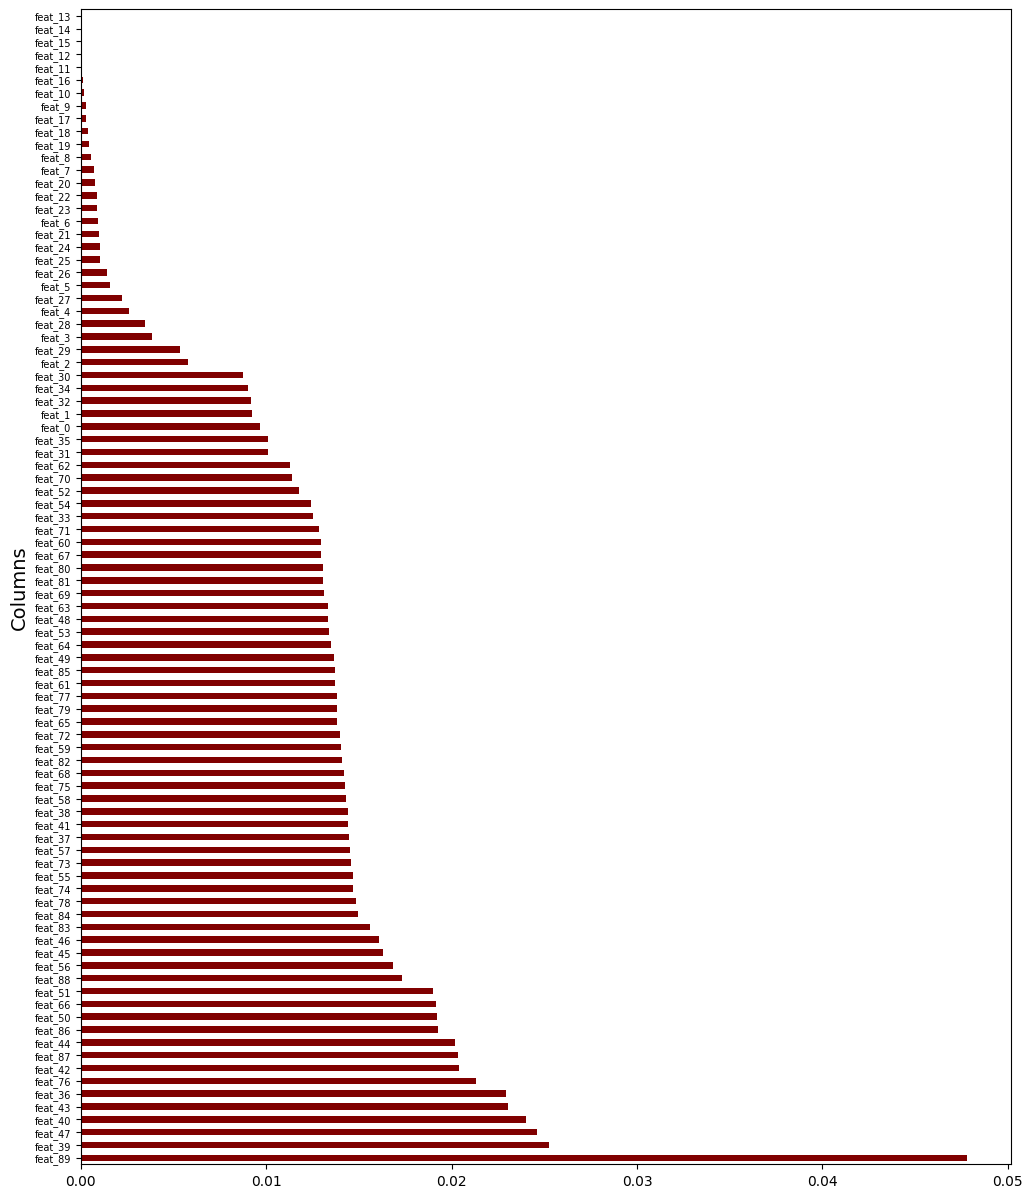

In [ ]:
plot_dir = Path('../data/plot')
plot_fi(fi);

In [6]:
fi[fi['imp'] < 0.005].size

52

----------------------------

### **Train/Test Split**

In [3]:
import sys
sys.path.insert(0, '../')

from data_preprocessing.sbss import SBSS

sbss = SBSS(
    df,
    non_pca_cols=['image_id', 'label'],
    random_state=21
    )

X_train, X_test, y_train, y_test = sbss.train_test_split(test_size=0.2)

In [4]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8477589, 91), (2076767, 90), (8477589,), (2076767,))

### **Handle Imbalance**

In [13]:
def undersampling_per_image(Xs, y, image_id='image_id', threshold=1.5, random_state=21):

    def func(x):
        df_non_manip = x[y.loc[x.index] == 0]
        df_manip = x[y.loc[x.index] == 1]
        manip_counts = len(df_manip)

        if len(df_manip) == 0:
            return pd.DataFrame()
        
        n_sample = min(int(manip_counts * threshold), len(df_non_manip))
        df_non_manip_reduced = df_non_manip.sample(n=n_sample, random_state=random_state)
        return pd.concat([df_manip, df_non_manip_reduced], axis=0)

    X_bal = Xs.groupby(image_id, group_keys=False, observed=True)\
                .apply(func, include_groups=False)\
                .reset_index(drop=True)
    y_bal = None
    
    return X_bal, y_bal

In [14]:
X_train_bal, y_train_bal = undersampling_per_image(X_train, y_train, threshold=1.5) # Try with thr: 2, 3, 4, 5

### **Normalization**

In [15]:
def minmax_norm(df, columns, eps=1e-6):
    df_norm = df.copy()
    for col in columns:
        if col in df_norm.columns:
            col_min, col_max = df_norm[col].min(), df_norm[col].max()
            norm = (df_norm[col] - col_min) / (col_max - col_min)
            df_norm[col] = norm * (1 - 2*eps) + eps

    return df_norm

In [16]:
norm_cols = X_train_bal.filter(like='feat_').columns
df_norm = minmax_norm(X_train_bal, norm_cols)

In [17]:
df_norm.describe()

,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_80,feat_81,feat_82,feat_83,feat_84,feat_85,feat_86,feat_87,feat_88,feat_89
count,1.541187e+06,1.541187e+06,1.541187e+06,1.541187e+06,1.541187e+06,1.541187e+06,1.541187e+06,1.541187e+06,1.541187e+06,1.541187e+06,...,1.541187e+06,1.541187e+06,1.541187e+06,1.541187e+06,1.541187e+06,1.541187e+06,1.541187e+06,1.541187e+06,1.541187e+06,1.541187e+06
mean,6.242572e-01,6.723998e-02,3.660824e-02,2.292530e-02,1.031241e-02,6.501856e-03,4.995530e-03,3.249460e-03,2.556745e-03,1.077134e-03,...,9.201080e-02,3.331138e-01,1.226398e-02,9.315336e-01,1.989952e-01,5.622113e-01,4.725363e-03,5.014271e-01,8.942457e-01,8.591287e-01
std,1.926095e-01,9.617399e-02,7.327375e-02,5.961284e-02,3.426347e-02,2.696176e-02,2.566254e-02,2.065963e-02,2.003809e-02,1.096204e-02,...,1.183745e-01,1.427099e-01,3.119670e-02,7.880881e-02,2.133777e-01,2.435292e-01,1.984683e-02,2.605071e-02,1.019605e-01,2.404218e-01
min,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,...,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06
25%,5.004995e-01,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,...,4.101654e-02,2.341395e-01,3.263629e-04,9.072677e-01,5.339473e-02,3.658045e-01,1.285762e-03,4.928993e-01,8.681962e-01,8.494493e-01
50%,6.163834e-01,1.342379e-02,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,...,6.054775e-02,3.413900e-01,1.940109e-03,9.600511e-01,1.187824e-01,5.503632e-01,1.965605e-03,5.004434e-01,9.226516e-01,9.812975e-01
75%,7.612382e-01,1.073833e-01,3.846246e-02,5.715274e-03,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,1.000000e-06,...,8.593833e-02,4.410877e-01,1.062712e-02,9.834928e-01,2.651895e-01,7.672957e-01,3.243342e-03,5.095604e-01,9.545084e-01,9.964772e-01
max,9.999990e-01,9.999990e-01,9.999990e-01,9.999990e-01,9.999990e-01,9.999990e-01,9.999990e-01,9.999990e-01,9.999990e-01,9.999990e-01,...,9.999990e-01,9.999990e-01,9.999990e-01,9.999990e-01,9.999990e-01,9.999990e-01,9.999990e-01,9.999990e-01,9.999990e-01,9.999990e-01


### Dataset Splitting

In [ ]:
kf = KFold(n_splits=5)
X_df = df_norm.iloc[:, 2:]
y = df_norm['label']

### Metrics Function

In [ ]:
def f1(pred, y):
    return f1_score(y, pred)
def m_f1(m, xs, y):
    return f1(m.predict(xs), y)

### Logistic Regression

In [ ]:
for i, (train_index, test_index) in enumerate(kf.split(X_df)):
    X_train, X_test = X_df.iloc[train_index, :], X_df.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train, y_train)

    score = m_f1(model, X_test, y_test)
    print(f"F1 of fold {i}:", score)

### Random Forest Classifier

In [ ]:
def rf(
        xs, y,
        n_estimators=100,
        max_samples=200000,
        max_features=0.5,
        min_samples_leaf=5,
        **kwargs
):
    return RandomForestClassifier(n_jobs=-1, n_estimators=n_estimators,
                                  max_samples=max_samples, max_features=max_features,
                                  min_samples_leaf=min_samples_leaf, oob_score=True).fit(xs, y)

In [ ]:
train_idx, test_idx = next(kf.split(X_df))
X_train, X_test = X_df.iloc[train_idx, :], X_df.iloc[test_idx, :]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [ ]:
m = rf(X_train, y_train)

In [ ]:
m_f1(m, X_train, y_train), m_f1(m, X_test, y_test)

In [ ]:
probas = np.stack([t.predict_proba(X_test.values) for t in m.estimators_])

In [ ]:
plt.plot([
    f1(np.argmax(probas[:i+1].mean(0), axis=1), y_test)
    for i in range(len(m.estimators_))
]);